In [ ]:
# ===========================
# Basic Libraries
# ===========================
import os
import cv2
import time
import warnings
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ===========================
# Feature Extraction
# ===========================
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

# ===========================
# Machine Learning Models
# ===========================
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ===========================
# Data Preprocessing
# ===========================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# ===========================
# Evaluation Metrics
# ===========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ===========================
# Display Settings
# ===========================
pd.set_option('display.max_columns', None)
plt.style.use("ggplot")

print("="*60)
print("All libraries imported successfully.")
print("="*60)

All libraries imported successfully.


In [2]:
# data set path
dataset_path = "BrainTumorDataset"
for root, dirs, files in os.walk(dataset_path):
    print(root)

BrainTumorDataset
BrainTumorDataset\Testing
BrainTumorDataset\Testing\glioma
BrainTumorDataset\Testing\meningioma
BrainTumorDataset\Testing\notumor
BrainTumorDataset\Testing\pituitary
BrainTumorDataset\Training
BrainTumorDataset\Training\glioma
BrainTumorDataset\Training\meningioma
BrainTumorDataset\Training\notumor
BrainTumorDataset\Training\pituitary


In [3]:
# Data set information on classes 
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

classes = sorted(os.listdir(train_path))

print("Classes Found")
print(classes)

print("\nNumber of Classes :", len(classes))

Classes Found
['glioma', 'meningioma', 'notumor', 'pituitary']

Number of Classes : 4


In [4]:
# image count
train_count = {}
test_count = {}

for cls in classes:
    train_count[cls] = len(os.listdir(os.path.join(train_path, cls)))
    test_count[cls] = len(os.listdir(os.path.join(test_path, cls)))

train_df = pd.DataFrame({
    "Training": train_count,
    "Testing": test_count
})

train_df

,Training,Testing
glioma,1400,400
meningioma,1400,400
notumor,1400,400
pituitary,1400,400


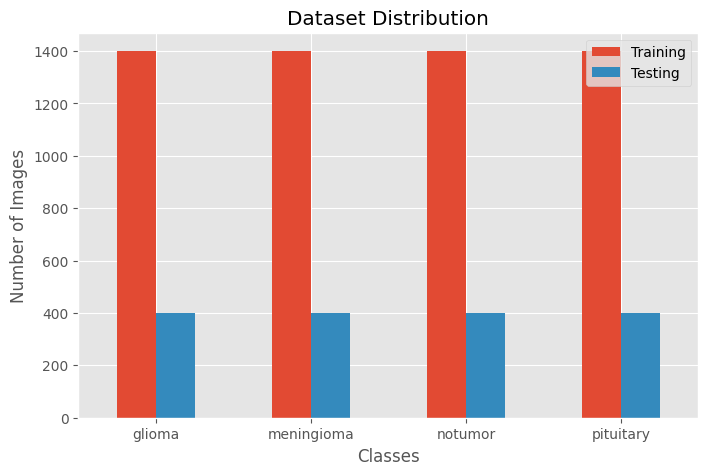

In [5]:
# above data in visulize 
fig, ax = plt.subplots(figsize=(8,5))

train_df.plot(kind='bar', ax=ax)

plt.title("Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.show()

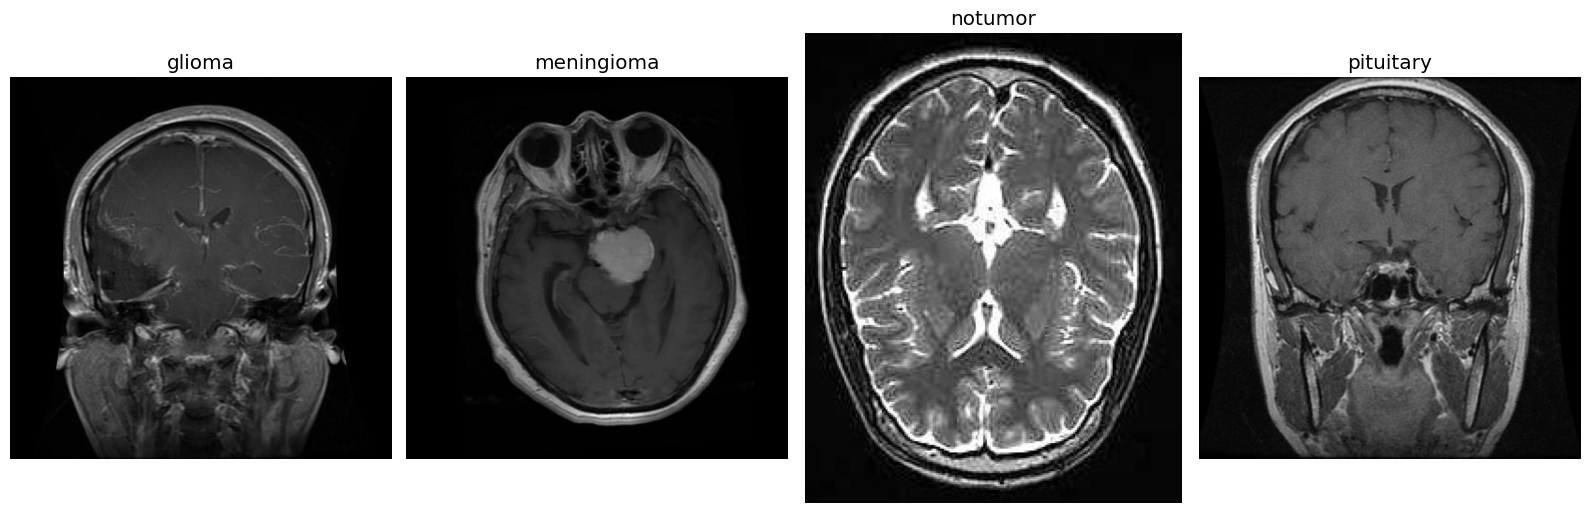

In [ ]:
# Display sample image
fig, axes = plt.subplots(1, len(classes), figsize=(16,5))

for i, cls in enumerate(classes):

    image_path = os.path.join(
        train_path,
        cls,
        os.listdir(os.path.join(train_path, cls))[0]
    )

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# image pre processing 
# Image Size
IMG_SIZE = 128

def preprocess_image(image_path):
    """
    Read image, resize, convert to grayscale
    """

    image = cv2.imread(image_path)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    return gray

In [8]:
# HOG feature
def extract_hog(image):

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    return features

In [9]:
# LBP Features
RADIUS = 2
N_POINTS = 8 * RADIUS

def extract_lbp(image):

    lbp = local_binary_pattern(
        image,
        N_POINTS,
        RADIUS,
        method='uniform'
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, N_POINTS + 3),
        range=(0, N_POINTS + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)

    return hist

In [ ]:
# GLCM Features 
def extract_glcm(image):
    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )
    contrast = graycoprops(glcm, 'contrast')[0,0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    correlation = graycoprops(glcm, 'correlation')[0,0]
    asm = graycoprops(glcm, 'ASM')[0,0]
    return np.array([
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        correlation,
        asm
    ])

In [11]:
# combain all features
def extract_features(image_path):

    image = preprocess_image(image_path)

    hog_features = extract_hog(image)

    lbp_features = extract_lbp(image)

    glcm_features = extract_glcm(image)

    features = np.concatenate([
        hog_features,
        lbp_features,
        glcm_features
    ])

    return features

In [12]:
# Load Dataset
X = []
y = []

for cls in classes:

    folder = os.path.join(train_path, cls)

    print(f"Loading {cls}...")

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        try:

            features = extract_features(image_path)

            X.append(features)

            y.append(cls)

        except:
            continue

Loading glioma...
Loading meningioma...
Loading notumor...
Loading pituitary...


In [ ]:
# Loading Testing Dataset
X_test = []
y_test = []

for cls in classes:

    folder = os.path.join(test_path, cls)

    print(f"Loading {cls}...")

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        try:

            features = extract_features(image_path)

            X_test.append(features)

            y_test.append(cls)

        except:
            continue

Loading glioma...
Loading meningioma...
Loading notumor...
Loading pituitary...


In [14]:
# convert the above data to numpy array
X = np.array(X)
X_test = np.array(X_test)

y = np.array(y)
y_test = np.array(y_test)

print("Training Shape :", X.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (5600, 8124)
Testing Shape : (1600, 8124)


In [15]:
# Label encoding
encoder = LabelEncoder()

y = encoder.fit_transform(y)

y_test = encoder.transform(y_test)

print("Classes")

for i, cls in enumerate(encoder.classes_):
    print(i, "->", cls)

Classes
0 -> glioma
1 -> meningioma
2 -> notumor
3 -> pituitary


In [16]:
# scaling features
scaler = StandardScaler()

X = scaler.fit_transform(X)

X_test = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [17]:
# Features summary
print("="*60)

print("Training Samples :", X.shape[0])

print("Testing Samples :", X_test.shape[0])

print("Number of Features :", X.shape[1])

print("Classes :", len(np.unique(y)))

print("="*60)

Training Samples : 5600
Testing Samples : 1600
Number of Features : 8124
Classes : 4


In [18]:
# ===============================
# Machine Learning Models
# ===============================

models = {

    "SVM": SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss'
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )

}

print(models.keys())

dict_keys(['SVM', 'Random Forest', 'Extra Trees', 'XGBoost', 'CatBoost'])


In [19]:
# Results 
results = []
trained_models = {}

In [20]:
# Training all models
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    print("="*70)
    print(f"Training : {name}")

    start = time.time()

    model.fit(X, y)

    end = time.time()

    training_time = end - start

    trained_models[name] = model

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )

    cv_score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    ).mean()

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "CV Accuracy": cv_score,
        "Training Time": training_time

    })

    print(f"Accuracy : {accuracy:.4f}")

Training : SVM
Accuracy : 0.9075
Training : Random Forest
Accuracy : 0.8456
Training : Extra Trees
Accuracy : 0.8494
Training : XGBoost
Accuracy : 0.8800
Training : CatBoost
Accuracy : 0.8150


In [21]:
#comparision Table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,CV Accuracy,Training Time
0,SVM,0.907500,0.915776,0.907500,0.903974,0.941964,578.359239
1,XGBoost,0.880000,0.887358,0.880000,0.875166,0.916250,627.769794
2,Extra Trees,0.849375,0.858718,0.849375,0.843276,0.892143,11.256417
3,Random Forest,0.845625,0.857944,0.845625,0.839034,0.889643,26.681570
4,CatBoost,0.815000,0.819990,0.815000,0.808753,NaN,744.273272


In [22]:
# Save all the results
results_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Comparison saved successfully.")

Comparison saved successfully.


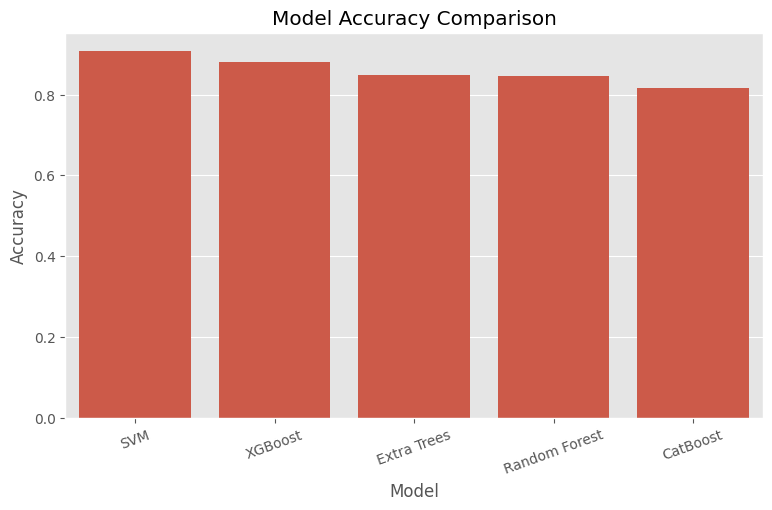

In [23]:
# accuracy comparision
plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

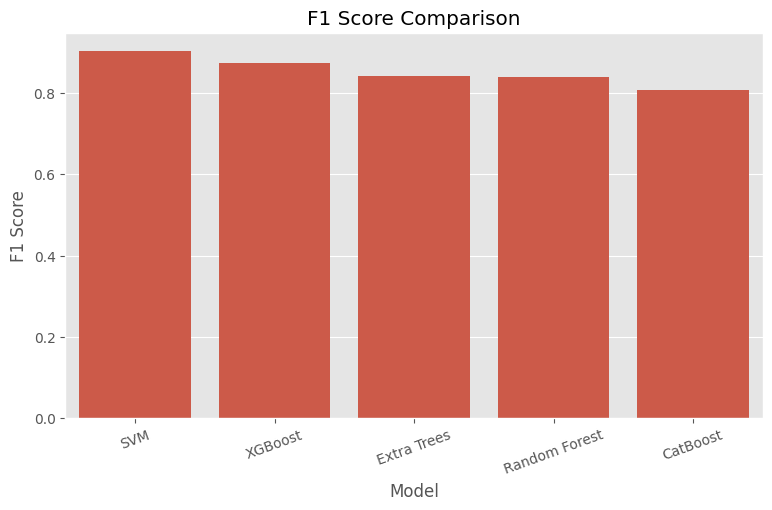

In [24]:
# F1 Score comparision
plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison")
plt.xticks(rotation=20)
plt.show()

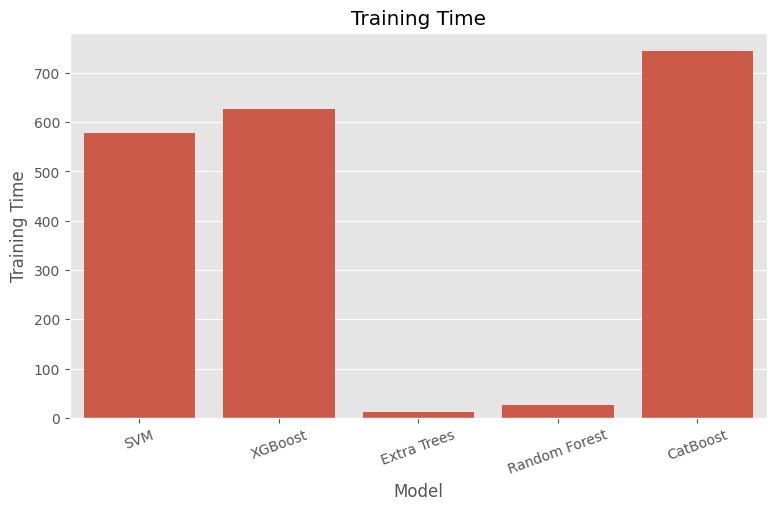

In [25]:
#Training time comparision
plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Training Time"
)

plt.title("Training Time")
plt.xticks(rotation=20)
plt.show()

In [26]:
# Select the best model
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

best_model = trained_models[best_model_name]

Best Model : SVM


In [27]:
# Save the best model
joblib.dump(best_model, "Best_BrainTumor_Model.pkl")
joblib.dump(scaler, "Scaler.pkl")
joblib.dump(encoder, "LabelEncoder.pkl")
print("Best model saved successfully.")

Best model saved successfully.


In [28]:
# Classification Report
prediction = best_model.predict(X_test)

print(classification_report(
    y_test,
    prediction,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

      glioma       0.98      0.70      0.82       400
  meningioma       0.85      0.95      0.89       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.90      1600
weighted avg       0.92      0.91      0.90      1600



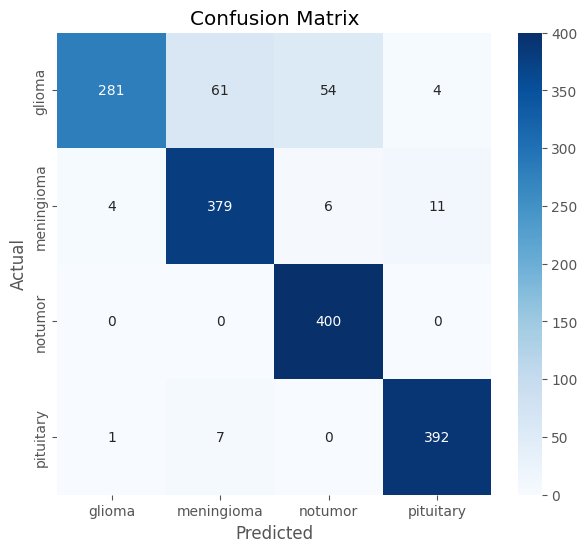

In [29]:
# confusion matrix
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
# Lode Saved files
import joblib

# Load saved artifacts
model = joblib.load("Best_BrainTumor_Model.pkl")
scaler = joblib.load("Scaler.pkl")
encoder = joblib.load("LabelEncoder.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [31]:
# feature extraction for single image
def prepare_single_image(image_path):
    """
    Extract features from a single image
    """

    features = extract_features(image_path)

    features = features.reshape(1, -1)

    features = scaler.transform(features)

    return features

In [32]:
# Prediction function
def predict_brain_tumor(image_path):

    # Extract features
    features = prepare_single_image(image_path)

    # Predict class
    prediction = model.predict(features)

    # Predict probabilities (if supported)
    probabilities = model.predict_proba(features)

    predicted_class = encoder.inverse_transform(prediction)[0]

    confidence = np.max(probabilities) * 100

    return predicted_class, confidence

In [33]:
# Image path.
image_path = r"BrainTumorDataset/Testing/glioma/Te-gl_17.jpg"

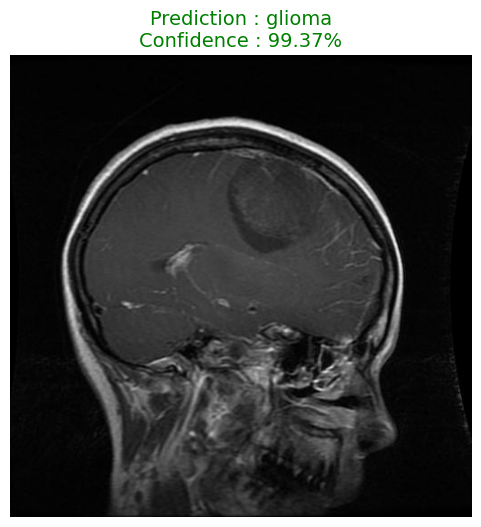

Predicted Class : glioma
Confidence      : 99.37%


In [34]:
# predict and display output.
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

prediction, confidence = predict_brain_tumor(image_path)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.axis("off")

plt.title(
    f"Prediction : {prediction}\nConfidence : {confidence:.2f}%",
    fontsize=14,
    color="green"
)
plt.show()
print(f"Predicted Class : {prediction}")
print(f"Confidence      : {confidence:.2f}%")

In [37]:
import os
import pandas as pd

image_folder = r"C:\Users\kisho\Desktop\NASSCOM\batch_3_year3\brain_tumor\validation"
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
results = []

for img_name in os.listdir(image_folder):
    if img_name.lower().endswith(image_extensions):
        img_path = os.path.join(image_folder, img_name)
        prediction, confidence = predict_brain_tumor(img_path)
        results.append({
            "Image Name": img_name,
            "Predicted Class": prediction,
            "Confidence (%)": round(confidence, 2)
        })
results_df = pd.DataFrame(results)
print(results_df)
# Save predictions
results_df.to_csv("Predictions.csv", index=False)
print("\nPredictions saved as 'Predictions.csv'")

      Image Name Predicted Class  Confidence (%)
0  Te-pi_144.jpg       pituitary           99.84
1   Te-pi_59.jpg       pituitary           99.45
2    Te-pi_6.jpg       pituitary           99.12

Predictions saved as 'Predictions.csv'
